# 01d L1B Waveform Components vs Refh Quality

Purpose:
- read the outputs from `detect_waveform_components.py`;
- summarize how waveform-derived component features relate to `good_snr` and `refh_snr`;
- optionally join transferred 3DEP labels by `pulse_index` when those products are available.

Scientific boundary:
- component rows and pulse summaries are waveform-derived diagnostics;
- they are not official georeferenced multi-return products.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

import laspy

%matplotlib inline

OUTPUT_DIR = CASALS_L1B_DIR / "outputs" / "detect_waveform_components"
PULSE_PATH = OUTPUT_DIR / "pulse_summary.parquet"
COMPONENT_PATH = OUTPUT_DIR / "component_table.parquet"
SWEEP_PATH = OUTPUT_DIR / "sweep_summary.csv"
H5_DIR = CASALS_L1B_DIR / "casals_h5_downloads"

assert PULSE_PATH.exists(), PULSE_PATH
assert COMPONENT_PATH.exists(), COMPONENT_PATH
assert SWEEP_PATH.exists(), SWEEP_PATH

In [2]:
pulse_df = pd.read_parquet(PULSE_PATH)
component_df = pd.read_parquet(COMPONENT_PATH)
sweep_df = pd.read_csv(SWEEP_PATH)

print("pulse_summary rows:", len(pulse_df))
print("component_table rows:", len(component_df))
print("sweep_summary rows:", len(sweep_df))

pulse_df.head()

pulse_summary rows: 768
component_table rows: 3807
sweep_summary rows: 3


,h5_filename,pulse_index,sweep_num,track_num,raw_argmax_bin,raw_argmax_amp,corrected_argmax_bin,n_components,main_peak_bin,main_peak_prominence,...,low_snr_flag,refh,refh_lon,refh_lat,refh_amp,refh_snr,good_snr,bg_mean,bg_std,refh_thres
0,casals_l1b_20241118T171757_001_02.h5,1280000,5000,0,1694.0,683.0,1694.0,5,1694.0,707.3065,...,True,-35.06403,-76.684602,36.188635,683.0,2.958109,False,-45.69746,92.196073,230.89076
1,casals_l1b_20241118T171757_001_02.h5,1280032,5000,1,1678.0,611.0,1678.0,5,1678.0,636.271425,...,True,-32.675986,-76.684603,36.188638,611.0,2.434548,False,-26.034996,92.3352,250.970603
2,casals_l1b_20241118T171757_001_02.h5,1280064,5000,2,1672.0,640.0,1672.0,5,1672.0,638.766449,...,True,-31.779329,-76.684604,36.18864,640.0,2.583749,False,-24.404772,90.702289,247.702094
3,casals_l1b_20241118T171757_001_02.h5,1280096,5000,3,2297.0,482.0,2297.0,5,2297.0,517.218909,...,True,-125.366028,-76.684642,36.188629,482.0,2.204402,False,-30.937649,83.197026,218.65343
4,casals_l1b_20241118T171757_001_02.h5,1280128,5000,4,1655.0,542.0,1655.0,5,1655.0,559.900511,...,True,-29.232423,-76.684603,36.188644,542.0,2.120193,False,-27.311091,94.316049,255.637055


In [3]:
good_snr_vs_components = (
    pulse_df.groupby("good_snr")["n_components"]
    .agg(["count", "mean", "median", "min", "max"])
)
good_snr_vs_clean = (
    pulse_df.groupby("good_snr")["has_clean_single_peak"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "fraction_clean_single_peak"})
)

refh_snr_bins = pd.cut(
    pulse_df["refh_snr"],
    bins=[-np.inf, 3, 5, 8, 12, np.inf],
    labels=["<3", "3-5", "5-8", "8-12", "12+"],
)
refh_snr_summary = (
    pulse_df.assign(refh_snr_bin=refh_snr_bins)
    .groupby("refh_snr_bin", observed=False)[["main_peak_prominence", "main_peak_width"]]
    .agg(["count", "median", "mean"])
)

display(good_snr_vs_components)
display(good_snr_vs_clean)
display(refh_snr_summary)

,count,mean,median,min,max
good_snr,,,,,
False,492,4.957317,5.0,2,5
True,276,4.956522,5.0,2,5


,count,fraction_clean_single_peak
good_snr,,
False,492,0.0
True,276,0.0


main_peak_prominence                           main_peak_width  \
                            count       median         mean           count   
refh_snr_bin                                                                  
<3                            260   622.038551   630.305698             260   
3-5                           232  1000.311214  1013.966775             232   
5-8                           166  1738.536465  1734.997376             166   
8-12                           96  2595.212134  2633.875667              96   
12+                            14  3622.957932  3882.709613              14   

                                   
                median       mean  
refh_snr_bin                       
<3            9.547076   10.74816  
3-5           9.963689  10.848069  
5-8            8.31065    8.87848  
8-12          8.054226   8.103224  
12+           8.270575   8.114082

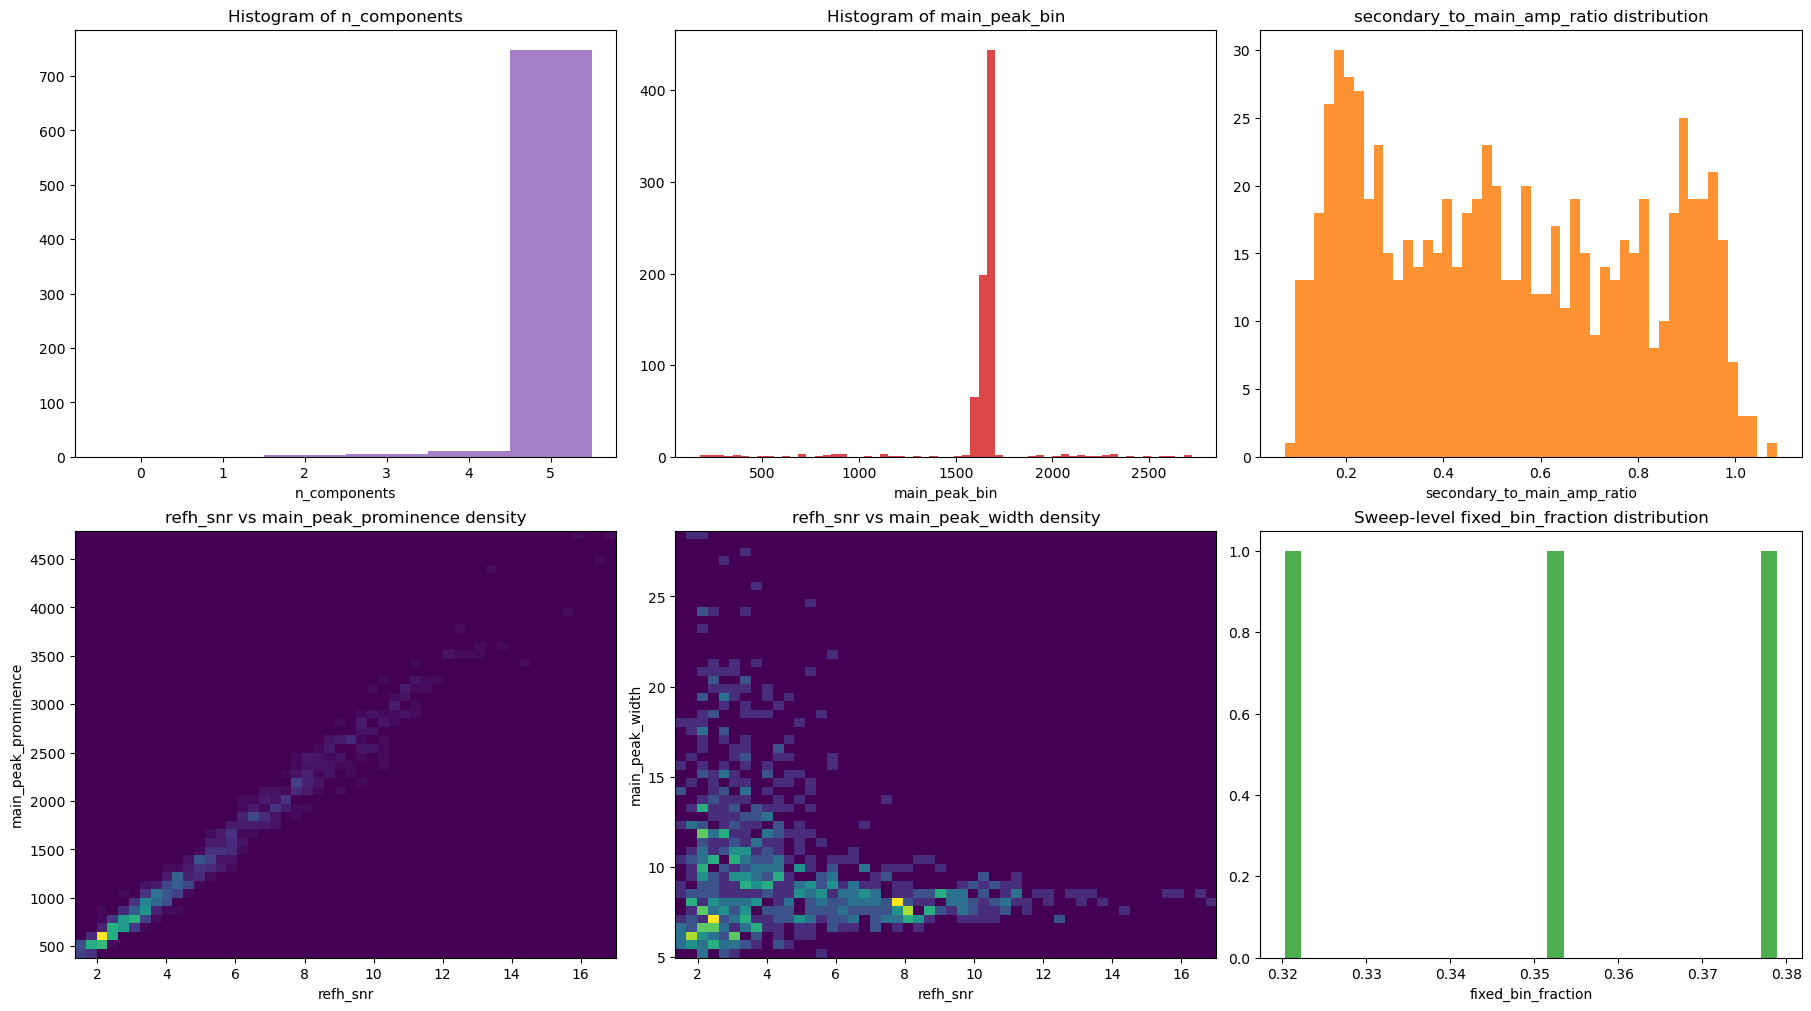

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

axes[0, 0].hist(pulse_df["n_components"].dropna(), bins=np.arange(-0.5, pulse_df["n_components"].max() + 1.5, 1.0), color="tab:purple", alpha=0.85)
axes[0, 0].set_title("Histogram of n_components")
axes[0, 0].set_xlabel("n_components")

axes[0, 1].hist(pulse_df["main_peak_bin"].dropna(), bins=60, color="tab:red", alpha=0.85)
axes[0, 1].set_title("Histogram of main_peak_bin")
axes[0, 1].set_xlabel("main_peak_bin")

axes[0, 2].hist(pulse_df["secondary_to_main_amp_ratio"].dropna(), bins=50, color="tab:orange", alpha=0.85)
axes[0, 2].set_title("secondary_to_main_amp_ratio distribution")
axes[0, 2].set_xlabel("secondary_to_main_amp_ratio")

axes[1, 0].hist2d(pulse_df["refh_snr"], pulse_df["main_peak_prominence"], bins=50, cmap="viridis")
axes[1, 0].set_title("refh_snr vs main_peak_prominence density")
axes[1, 0].set_xlabel("refh_snr")
axes[1, 0].set_ylabel("main_peak_prominence")

axes[1, 1].hist2d(pulse_df["refh_snr"], pulse_df["main_peak_width"], bins=50, cmap="viridis")
axes[1, 1].set_title("refh_snr vs main_peak_width density")
axes[1, 1].set_xlabel("refh_snr")
axes[1, 1].set_ylabel("main_peak_width")

axes[1, 2].hist(sweep_df["fixed_bin_fraction"].dropna(), bins=30, color="tab:green", alpha=0.85)
axes[1, 2].set_title("Sweep-level fixed_bin_fraction distribution")
axes[1, 2].set_xlabel("fixed_bin_fraction")

plt.show()

,example_name,pulse_index,sweep_num,track_num,n_components,main_peak_bin,main_peak_prominence,main_peak_width,refh_snr
0,multi_peak,1280000,5000,0,5,1694.0,707.306500,6.325945,2.958109
1,broad_peak,1280032,5000,1,5,1678.0,636.271425,20.129588,2.434548


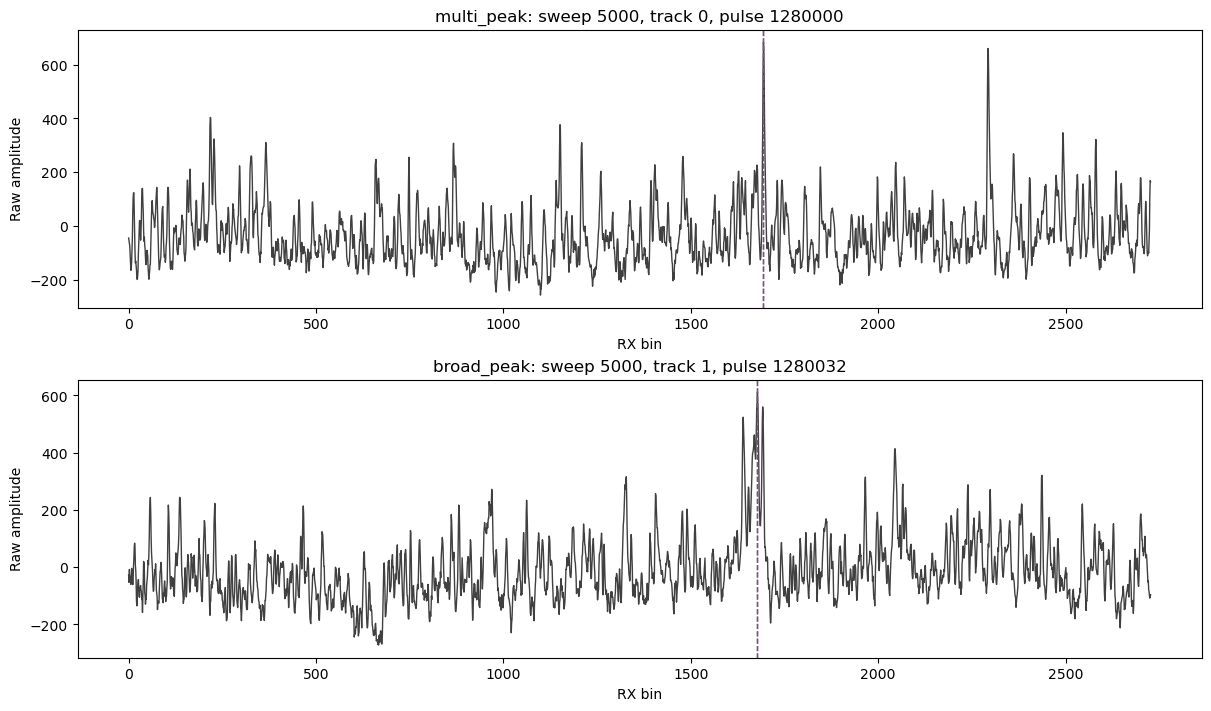

No stripe-like sweeps were flagged in the current sweep summary.


In [5]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import build_record_index_grid, infer_waveform_record_axis, read_waveform_records, require_dataset

example_queries = [
    ("clean_single_peak", pulse_df.loc[pulse_df["has_clean_single_peak"].fillna(False)].head(1)),
    ("multi_peak", pulse_df.loc[pulse_df["has_multiple_prominent_peaks"].fillna(False)].head(1)),
    ("broad_peak", pulse_df.loc[pulse_df["has_broad_main_peak"].fillna(False)].head(1)),
]
stripe_examples = sweep_df.loc[sweep_df["stripe_like_flag"].fillna(False)].head(1)

def plot_example_waveforms(example_rows):
    if not example_rows:
        print("No waveform examples available.")
        return
    h5_filename = example_rows[0]["h5_filename"]
    h5_path = H5_DIR / h5_filename
    if not h5_path.exists():
        print("Original H5 not found for waveform examples:", h5_path)
        return
    with h5py.File(h5_path, "r") as h5:
        info = build_record_index_grid(h5)
        rx_ds = require_dataset(h5, "rx_waveform")
        rx_record_axis = infer_waveform_record_axis(rx_ds, info.n_records)
        fig, axes = plt.subplots(len(example_rows), 1, figsize=(12, 3.5 * len(example_rows)), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, row in zip(axes, example_rows):
            pulse_index = int(row["pulse_index"])
            waveform = read_waveform_records(rx_ds, rx_record_axis, [pulse_index])[0]
            ax.plot(waveform, color="0.25", linewidth=1.0)
            ax.axvline(float(row["main_peak_bin"]), color="tab:red", linestyle="--", linewidth=1.0)
            ax.axvline(float(row["raw_argmax_bin"]), color="tab:blue", linestyle="--", linewidth=1.0)
            ax.set_title(
                f"{row['example_name']}: sweep {int(row['sweep_num'])}, track {int(row['track_num'])}, pulse {pulse_index}"
            )
            ax.set_xlabel("RX bin")
            ax.set_ylabel("Raw amplitude")
        plt.show()

example_rows = []
for example_name, frame in example_queries:
    if frame.empty:
        continue
    row = frame.iloc[0].to_dict()
    row["example_name"] = example_name
    example_rows.append(row)

if example_rows:
    display(pd.DataFrame(example_rows)[[
        "example_name", "pulse_index", "sweep_num", "track_num", "n_components",
        "main_peak_bin", "main_peak_prominence", "main_peak_width", "refh_snr"
    ]])
    plot_example_waveforms(example_rows)
else:
    print("No clean/multi/broad examples were available in the current pulse summary.")

if stripe_examples.empty:
    print("No stripe-like sweeps were flagged in the current sweep summary.")
else:
    display(stripe_examples)

In [6]:
h5_stems = pulse_df["h5_filename"].str.replace(".h5", "", regex=False).unique().tolist()
joined_frames = []

for stem in h5_stems:
    laz_path = CASALS_L1B_DIR / "outputs" / "transfer_3dep_labels_to_casals" / f"{stem}.laz"
    if not laz_path.exists():
        continue
    las = laspy.read(laz_path)
    if "point_index" not in las.point_format.dimension_names:
        continue
    labels = pd.DataFrame({
        "pulse_index": np.asarray(las["point_index"]),
        "transferred_class": np.asarray(las.classification, dtype=np.uint8),
    })
    labels["h5_filename"] = f"{stem}.h5"
    joined_frames.append(labels)

if not joined_frames:
    print("No transferred 3DEP label products were found. Skipping the optional join section.")
else:
    label_df = pd.concat(joined_frames, ignore_index=True)
    joined = pulse_df.merge(label_df, on=["h5_filename", "pulse_index"], how="inner")
    display(
        joined.groupby("transferred_class")[["n_components", "main_peak_prominence", "main_peak_width"]]
        .agg(["count", "median", "mean"])
    )
    noise = joined.loc[joined["transferred_class"] == 7]
    ground = joined.loc[joined["transferred_class"] == 2]
    print("noise class vs peak_count/stripe_score:")
    display(noise[["n_components", "main_peak_prominence", "main_peak_width"]].describe())
    print("ground class vs clean_single_peak:")
    display(ground["has_clean_single_peak"].value_counts(dropna=False))

n_components                  main_peak_prominence  \
                         count median      mean                count   
transferred_class                                                      
1                          357    5.0  4.971989                  357   
2                          281    5.0  4.960854                  281   
7                          130    5.0  4.907692                  130   

                                            main_peak_width             \
                        median         mean           count     median   
transferred_class                                                        
1                   877.171491   975.087581             357  10.503802   
2                  1935.494089  1975.046494             281   8.040657   
7                    625.45592   701.884657             130   7.864801   

                             
                       mean  
transferred_class            
1                  11.73764  
2                  8.095211  
7                  9.319355

noise class vs peak_count/stripe_score:


,n_components,main_peak_prominence,main_peak_width
count,130.0,130.0,130.0
mean,4.907692,701.884657,9.319355
std,0.456582,251.616905,3.760861
min,2.0,382.512282,4.958
25%,5.0,527.630169,6.35649
50%,5.0,625.45592,7.864801
75%,5.0,795.503189,11.284207
max,5.0,1888.180934,21.096276


ground class vs clean_single_peak:


has_clean_single_peak
False    281
Name: count, dtype: Int64